# Proyek Akhir: Klasifikasi Gambar (Image Classification)

- **Nama:** R. Haikal Rizki Tri Hartanto
- **Dataset:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)
- **Kriteria yang Dipenuhi:**
  - Dataset berisi lebih dari 10.000 gambar (~25.000 gambar).
  - Resolusi gambar pada dataset tidak seragam.
  - Memiliki lebih dari 3 kelas (6 kelas: buildings, forest, glacier, mountain, sea, street).
  - Menggunakan model *Sequential*, *Conv2D*, dan *MaxPooling2D*.
  - Menggunakan *Callback* untuk menghentikan *training* saat akurasi > 95%.
  - Menyertakan plot akurasi dan *loss*.
  - Menyimpan model dalam format SavedModel, TF-Lite, dan TFJS.
  - Melakukan pengujian (inferensi) pada model.

## Import Library


In [1]:
# Import library dasar dan visualisasi
import os
import pathlib
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import library TensorFlow dan Keras
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import library Google Colab
from google.colab import files

# Mengabaikan warning system yang tidak perlu
warnings.filterwarnings('ignore')

print(f"Versi TensorFlow yang digunakan: {tf.__version__}")

Versi TensorFlow yang digunakan: 2.19.0


## 1. Mengunduh dan Menyiapkan Dataset dari Kaggle
Mengunduh dataset Intel Image Classification langsung menggunakan Kaggle API dan mengekstraknya ke dalam direktori lokal Colab.

In [2]:
# Upload kredensial Kaggle
files.upload()

# Setup direktori untuk Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dan ekstrak dataset
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q -o intel-image-classification.zip -d dataset
print("Dataset siap digunakan.")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 93% 321M/346M [00:00<00:00, 609MB/s]
100% 346M/346M [00:00<00:00, 645MB/s]
Dataset siap digunakan.


## 2. Preprocessing Data dan Image Augmentation
Menggunakan `ImageDataGenerator` untuk membagi data menjadi *train set* dan *validation set*, serta menerapkan augmentasi gambar untuk mencegah *overfitting*.

In [3]:
# Path ke dataset
train_dir = 'dataset/seg_train/seg_train'
val_dir = 'dataset/seg_test/seg_test'

# Augmentasi untuk data latih
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Validasi hanya menggunakan rescale
test_datagen = ImageDataGenerator(rescale=1./255)

# Setup data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 3. Arsitektur Model CNN
Membangun model klasifikasi gambar menggunakan arsitektur `Sequential` dengan kombinasi layer `Conv2D` dan `MaxPooling2D`.

In [4]:
model = tf.keras.models.Sequential([
    # Layer Konvolusi Pertama
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Layer Konvolusi Kedua
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Layer Konvolusi Ketiga
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Layer Konvolusi Keempat
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Meratakan hasil konvolusi (Flatten)
    tf.keras.layers.Flatten(),

    # Dropout untuk mencegah overfitting
    tf.keras.layers.Dropout(0.5),

    # Hidden layer
    tf.keras.layers.Dense(512, activation='relu'),

    # Output layer dengan 6 neuron (karena ada 6 kelas) dan fungsi aktivasi softmax
    tf.keras.layers.Dense(6, activation='softmax')
])

# Mengkompilasi model
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Melihat ringkasan arsitektur model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Implementasi Callback dan Proses Training
Menggunakan kustom *callback* untuk menghentikan pelatihan (*early stopping*) secara otomatis ketika akurasi pada *training set* dan *validation set* sudah melebihi 95% untuk efisiensi waktu.

In [5]:
# Custom callback untuk early stopping
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.95 and logs.get('val_accuracy') >= 0.95):
            print("\n[INFO] Target akurasi >= 95% tercapai. Menghentikan proses training.")
            self.model.stop_training = True

callbacks = TargetCallback()

# Eksekusi training model
print("Memulai proses training model...")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),  # Total batch per epoch
    epochs=50,                             # Batas maksimal epoch
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[callbacks]
)

Memulai proses training model...
Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 96s 203ms/step - accuracy: 0.5724 - loss: 1.0910 - val_accuracy: 0.6573 - val_loss: 0.8987
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 191ms/step - accuracy: 0.6801 - loss: 0.8377 - val_accuracy: 0.7563 - val_loss: 0.6799
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.7351 - loss: 0.7190 - val_accuracy: 0.7833 - val_loss: 0.6141
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 83s 187ms/step - accuracy: 0.7639 - loss: 0.6429 - val_accuracy: 0.8027 - val_loss: 0.5404
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.7826 - loss: 0.5949 - val_accuracy: 0.8227 - val_loss: 0.5062
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.8013 - loss: 0.5558 - val_accuracy: 0.8360 - val_loss: 0.4752
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 188ms/step - accuracy: 0.8089 - loss: 0.5283 - val_accuracy: 0.8380 - val_loss: 0.4690
Epoch 8/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/

## 5. Visualisasi Akurasi dan Loss
Membuat plot untuk melihat pergerakan metrik `accuracy` dan `loss` pada *training set* dan *validation set* selama proses *training* berlangsung.

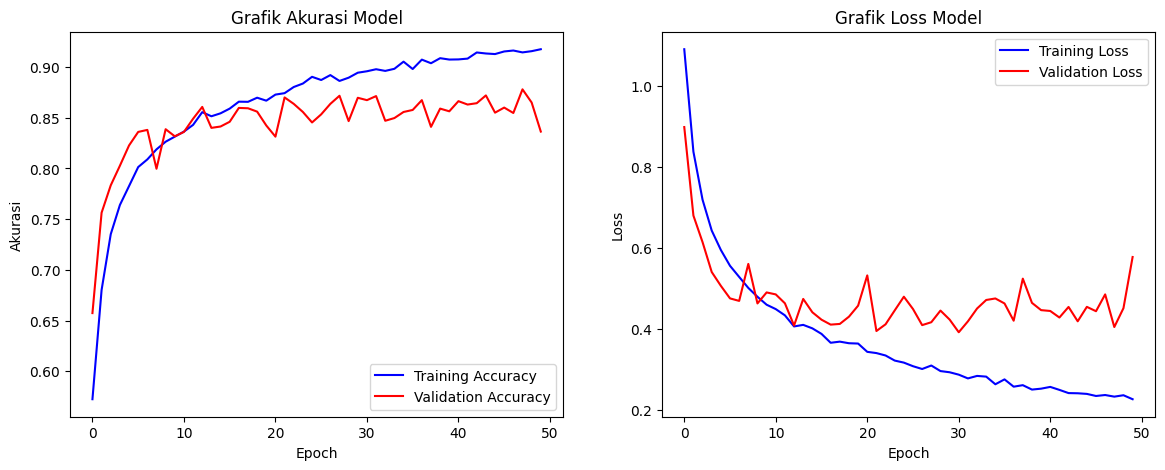

In [6]:
plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Grafik Akurasi Model')
plt.ylabel('Akurasi')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Grafik Loss Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

## 6. Inferensi Model (Uji Coba Prediksi)
Menguji model yang telah dilatih menggunakan gambar baru yang diunggah secara interaktif untuk melihat apakah model dapat mengklasifikasikan gambar tersebut dengan benar sesuai dengan 6 kelas yang ada (buildings, forest, glacier, mountain, sea, street).

Silakan unggah gambar (bangunan, hutan, gletser, gunung, laut, atau jalanan) untuk diprediksi!


Saving dbs tower.jpg to dbs tower.jpg


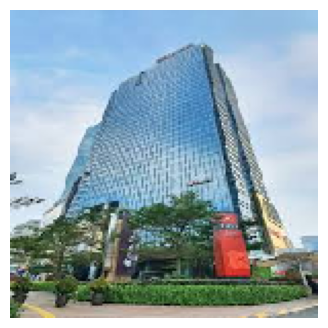

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step

Nama File: dbs tower.jpg
Probabilitas tiap kelas:
- BUILDINGS: 98.56%
- FOREST: 0.01%
- GLACIER: 0.03%
- MOUNTAIN: 1.25%
- SEA: 0.15%
- STREET: 0.00%

Hasil Prediksi Akhir: **BUILDINGS**


In [7]:
print("Silakan unggah gambar (bangunan, hutan, gletser, gunung, laut, atau jalanan) untuk diprediksi!")
uploaded = files.upload()

for fn in uploaded.keys():
    # Load dan tampilkan gambar
    path = fn
    img = image.load_img(path, target_size=(150, 150))

    plt.figure(figsize=(4,4))
    imgplot = plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Preprocessing gambar untuk prediksi
    x = image.img_to_array(img)
    x = x / 255.0 # Normalisasi Piksel
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])

    # Eksekusi prediksi
    classes = model.predict(images, batch_size=10)
    class_labels = list(train_generator.class_indices.keys())

    print(f"\nNama File: {fn}")
    print("Probabilitas tiap kelas:")
    for i, label in enumerate(class_labels):
        print(f"- {label.upper()}: {classes[0][i] * 100:.2f}%")

    predicted_class_index = np.argmax(classes[0])
    predicted_class_name = class_labels[predicted_class_index]

    print(f"\nHasil Prediksi Akhir: **{predicted_class_name.upper()}**")

## 7. Ekspor dan Simpan Model
Menyimpan model yang sudah dilatih ke dalam format `SavedModel`, lalu mengonversinya ke format `TF-Lite` (untuk perangkat *mobile/embedded*) dan `TFJS` (untuk *browser/web*).

In [8]:
# Export ke SavedModel (Metode update untuk Keras 3)
export_dir = 'saved_model/'
model.export(export_dir)
print("[INFO] Model berhasil disimpan dalam format SavedModel.")

# Export ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_dir = pathlib.Path('tflite/')
tflite_dir.mkdir(exist_ok=True, parents=True)
tflite_model_file = tflite_dir / "model.tflite"
tflite_model_file.write_bytes(tflite_model)
print("[INFO] Model berhasil dikonversi dan disimpan dalam format TF-Lite.")

# Export ke TFJS
!pip install tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model saved_model/ tfjs_model/
print("[INFO] Model berhasil dikonversi dan disimpan dalam format TFJS.")

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138970076861776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076862352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076861968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076864464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076863696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076865424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076864848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076865040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076865232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076866384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138970076867152: T

2026-03-13 06:04:06.722705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773381846.743074   21901 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773381846.749755   21901 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773381846.766075   21901 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773381846.766096   21901 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773381846.766100   21901 computation_placer.cc:177] computation placer alr

## 8. Setup & Build Submission
Meng-*generate* daftar dependensi (`requirements.txt`), label kelas untuk TFLite (`label.txt`), serta dokumentasi proyek (`README.md`). Seluruh *artifact* model kemudian disusun ke dalam struktur direktori *submission* yang disyaratkan dan dikompilasi menjadi satu file ZIP.

In [10]:
# Ekspor requirements
!pip freeze > requirements.txt

# Setup struktur direktori submission
!mkdir -p submission/tflite
!mkdir -p submission/tfjs_model
!mkdir -p submission/saved_model

# Copy artifacts ke direktori submission
!cp -r saved_model/* submission/saved_model/
!cp -r tfjs_model/* submission/tfjs_model/
!cp -r tflite/* submission/tflite/
!cp requirements.txt submission/

# Generate label.txt untuk TFLite berdasarkan class_indices
class_names = list(train_generator.class_indices.keys())
with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(class_names))
print("[INFO] label.txt generated.")

# Generate README.md
readme_content = """# Proyek Klasifikasi Gambar
Submission Belajar Fundamental Deep Learning - Dicoding.
- **Dataset**: Intel Image Classification
- **Arsitektur**: CNN
"""
with open('submission/README.md', 'w') as f:
    f.write(readme_content)
print("[INFO] README.md generated.")

# Compress direktori menjadi zip
!zip -q -r "Proyek Klasifikasi Gambar_R. Haikal Rizki Tri Hartanto.zip" submission/
print("\n[INFO] Proses build ZIP submission selesai.")

[INFO] label.txt generated.
[INFO] README.md generated.

[INFO] Proses build ZIP submission selesai.
